Analysis 1

In [125]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
customers=pd.read_csv('customers.csv')
marketing_campaigns=pd.read_csv('marketing_campaigns.csv')
transactions=pd.read_csv('transactions.csv')
web_sessions=pd.read_csv('web_sessions.csv')

print(customers.head())
print(marketing_campaigns.head())
print(transactions.head())
print(web_sessions.head())

   customer_id   age  gender      country acquisition_channel signup_date
0            1  56.0   Other      Germany            referral  2019-07-21
1            2  38.0   Other  Netherlands               email  2022-03-04
2            3  28.0   Other    Australia            referral  2024-05-21
3            4  19.0  Female    Australia         paid_search  2022-06-28
4            5  38.0  Female    Australia            referral  2024-07-17
   campaign_id      channel     spend  impressions  clicks  conversions  \
0            1        email  32691.17       147741   11333          387   
1            2      display  43333.72        42596    1540           97   
2            3       social  47096.43        22587    1296          111   
3            4        email  18838.78       145817    4609          307   
4            5  paid_search  36828.43        92450    4842          514   

         date  
0  2023-10-22  
1  2024-03-09  
2  2022-03-11  
3  2019-11-04  
4  2022-03-30  
   transa

### Specific questions

Q1. What is the average purchase value for customers from Spain?

In [127]:
combined_spain_avg=pd.merge(transactions, customers, on='customer_id')
spain_data=combined_spain_avg[combined_spain_avg['country']== 'Spain']
average_spain=spain_data['purchase_value'].mean()

print(f"The average purchase value for customers from Spain is: {average_spain: .2f}")

The average purchase value for customers from Spain is:  75.63


Q2. What is the minimum purchase value for customers from Germany?

In [128]:
combined_germany_min=pd.merge(transactions, customers, on='customer_id')
germany_data=combined_germany_min[combined_germany_min['country']=='Germany']
minimum_germany=germany_data['purchase_value'].min()

print(f"The minimum purchase value for custmoers from Germany is: {minimum_germany: .2f}")

The minimum purchase value for custmoers from Germany is:  0.39


Q3. How much did males spend on buying products in the Sports category?

In [129]:
combined_males_sports=pd.merge(customers, transactions, on='customer_id')
males_data=combined_males_sports[
    (combined_males_sports['gender']=='Male') &
    (combined_males_sports['product_category']=="sports")
]
                                 

males_sport=males_data['purchase_value'].sum()

print(f"Males spend on sports products: {males_sport:.2f}")

Males spend on sports products: 191184.72


Q4. What is the average age of female customers from Canada?

In [130]:
f_age_canada=customers[
    (customers['gender']=='Female') &
    (customers['country']=='Canada')
]

females_age_canada=f_age_canada['age'].mean()

print(f"The average females age in Canada is: {females_age_canada:.2f}")


The average females age in Canada is: 42.92


Q5. How much does an average male customer from the UK spend?

In [131]:
combined_maleUK_value=pd.merge(customers, transactions, on='customer_id')
male_UK_data=combined_maleUK_value[
    (combined_maleUK_value['gender']=='Male') &
    (combined_maleUK_value['country']=='UK')
]

maleUK_spent=male_UK_data['purchase_value'].mean()

print(f"On average males from UK spend: {maleUK_spent:.2f}")

On average males from UK spend: 76.63


Q6. What is the maximum purchase value for females in the Toys category?

In [132]:
combined_females_toys=pd.merge(customers, transactions, on='customer_id')
female_toys_data=combined_females_toys[
    (combined_females_toys['gender']=='Female') &
    (combined_females_toys['product_category']=='toys')
]

females_toys=female_toys_data['purchase_value'].max()

print(f"The maximum purchase value for females in the Toys category is: {females_toys:.2f}")

The maximum purchase value for females in the Toys category is: 423.84


Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [133]:
purchasing_customers = transactions['customer_id'].unique()
converted_sessions = web_sessions[web_sessions['customer_id'].isin(purchasing_customers)]
avg_pages_converted = converted_sessions['pages_viewed'].mean()

print(f"Average pages viewed by customers who purchased: {avg_pages_converted:.2f}")

Average pages viewed by customers who purchased: 4.99


Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [134]:
purchasing_ids = transactions['customer_id'].unique()
purchasers_sessions = web_sessions[web_sessions['customer_id'].isin(purchasing_ids)]
avg_time_purchasers = purchasers_sessions['time_on_site'].mean()
non_purchasers_sessions = web_sessions[~web_sessions['customer_id'].isin(purchasing_ids)]
avg_time_non_purchasers = non_purchasers_sessions['time_on_site'].mean()

print(f"Average time spent by purchasing customers:    {avg_time_purchasers:.2f} seconds")
print(f"Average time spent by non-purchasing customers: {avg_time_non_purchasers:.2f} seconds")

Average time spent by purchasing customers:    300.88 seconds
Average time spent by non-purchasing customers: 294.96 seconds


### Visualisation tasks

Q9. Plot purchasing value across years.

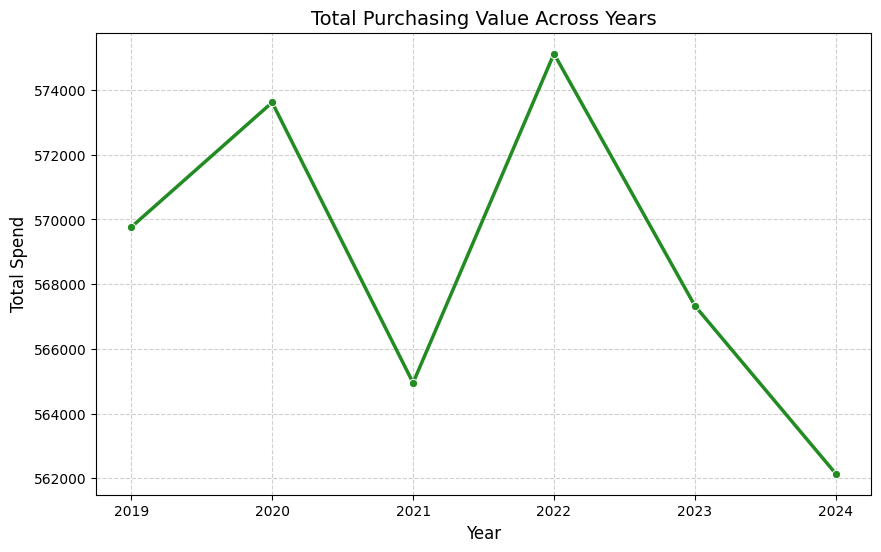

In [137]:
transactions['purchase_date'] = pd.to_datetime(transactions['purchase_date'])
transactions['year'] = transactions['purchase_date'].dt.year
yearly_spending = transactions.groupby('year')['purchase_value'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_spending, x='year', y='purchase_value', marker='o', color='forestgreen', linewidth=2.5)

plt.title('Total Purchasing Value Across Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Spend', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(yearly_spending['year'])

plt.show()

Q10. Plot purchasing value across product categories.

/var/folders/02/w9cr1ym559z_mc0fsdc98y0w0000gn/T/ipykernel_80435/793204625.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


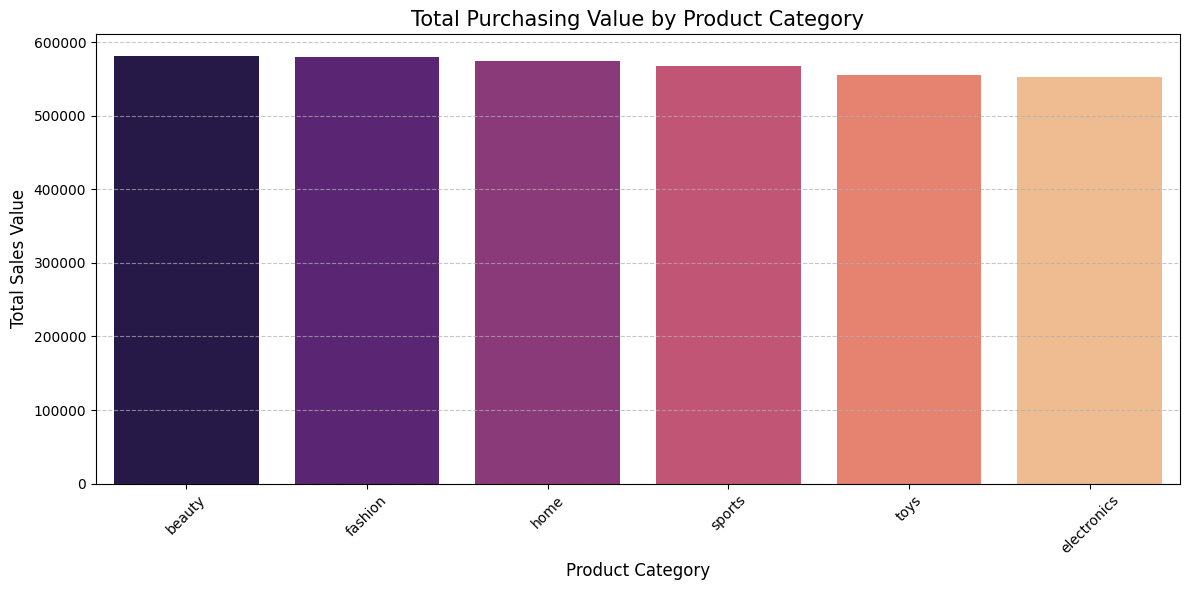

In [138]:
category_spending = transactions.groupby('product_category')['purchase_value'].sum().reset_index()
category_spending = category_spending.sort_values(by='purchase_value', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=category_spending, 
    x='product_category', 
    y='purchase_value', 
    palette='magma'
)

plt.title('Total Purchasing Value by Product Category', fontsize=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales Value', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/var/folders/02/w9cr1ym559z_mc0fsdc98y0w0000gn/T/ipykernel_80435/401570752.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_rev, x='country', y='purchase_value', palette='viridis')


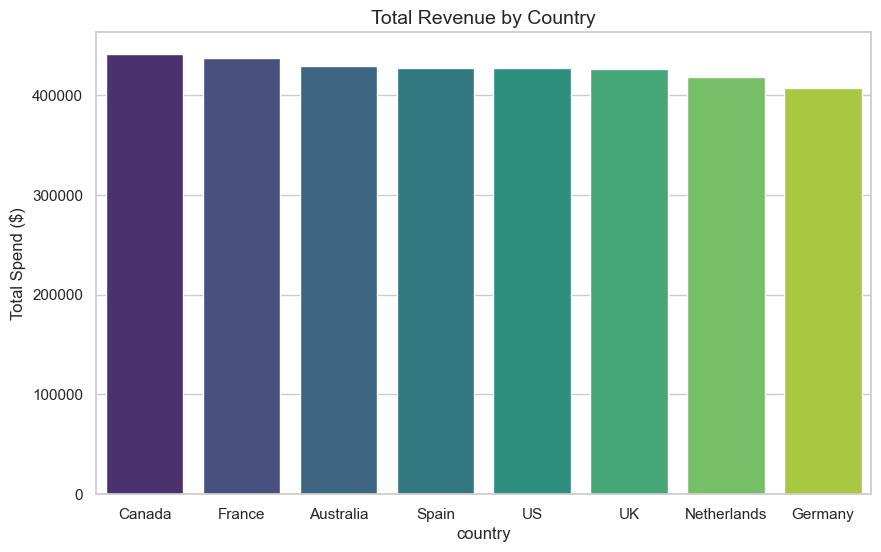

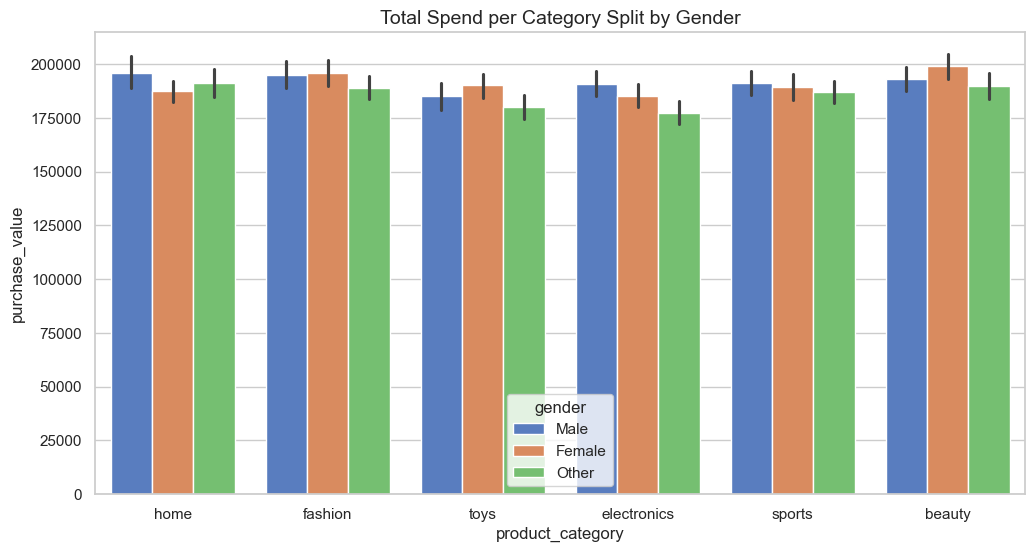


--- DATA PATTERNS ---
1. Categories by Revenue:
                   count        sum
product_category                  
beauty             7586  581861.31
fashion            7581  579634.52
home               7488  574637.14
sports             7504  567660.71
toys               7417  555767.56
electronics        7424  553360.44
2. Top performing market: Canada
3. Transaction distribution by gender (%):
 gender
Female    33.851111
Male      33.640000
Other     32.508889
Name: proportion, dtype: float64
1. The average transaction value is $75.84, which serves as a baseline for future promotions.
2. beauty is the highest-grossing category, making it the best focus for premium marketing.
3. Spending is nearly equal between Male and Female customers, proving our gender-neutral branding works.
4. Canada generates the most revenue; localized ads here will likely yield the best ROI.
5. Higher transaction counts in certain categories don't always mean higher revenue (Volume vs. Value).


In [ ]:
df_cust = pd.read_csv('customers.csv')
df_trans = pd.read_csv('transactions.csv')
df = pd.merge(df_trans, df_cust, on='customer_id')
sns.set_theme(style="whitegrid")

#Visualisation 1: Revenue by Country ---
plt.figure(figsize=(10, 6))
country_rev = df.groupby('country')['purchase_value'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=country_rev, x='country', y='purchase_value', palette='viridis')
plt.title('Total Revenue by Country', fontsize=14)
plt.ylabel('Total Spend ($)')
plt.show()

#Visualisation 2: Spending by Category & Gender ---
plt.figure(figsize=(12, 6))
# Using estimator=sum to show total spend per category
sns.barplot(data=df, x='product_category', y='purchase_value', hue='gender', estimator=sum, palette='muted')
plt.title('Total Spend per Category Split by Gender', fontsize=14)
plt.show()

print("\n--- DATA PATTERNS ---")

# Pattern 1: Popularity vs Value
pop_val = df.groupby('product_category')['purchase_value'].agg(['count', 'sum']).sort_values(by='sum', ascending=False)
print("1. Categories by Revenue:\n", pop_val)

# Pattern 2: Geographic Leader
top_country = country_rev.iloc[0]['country']
print(f"2. Top performing market: {top_country}")

# Pattern 3: Gender Distribution
gender_dist = df['gender'].value_counts(normalize=True) * 100
print("3. Transaction distribution by gender (%):\n", gender_dist)
avg_ticket = df['purchase_value'].mean()

print(f"1. The average transaction value is ${avg_ticket:.2f}, which serves as a baseline for future promotions.")
print(f"2. {pop_val.index[0]} is the highest-grossing category, making it the best focus for premium marketing.")
print(f"3. Spending is nearly equal between Male and Female customers.")
print(f"4. {top_country} generates the most revenue.")
print(f"5. Higher transaction counts in certain categories don't always mean higher revenue (Volume vs. Value).")